In [13]:
import pandas as pd
PATH  = r"C:\Users\swl00\IFPRI Dropbox\Weilun Shi\Kenya-MUAC data\Processed_data\HHA_all.dta"
data = pd.read_stata(PATH)

In [14]:
data.columns.tolist()

['qid',
 'county',
 'subcounty',
 'ward',
 'livelihoodzone',
 'month',
 'year',
 'lat',
 'Long',
 'interviewdate',
 'householdcode',
 'householdname',
 'householdhead',
 'respondentname',
 'headeducationlevel',
 'mainhhincomesource',
 'headgender',
 'respondentgender',
 'malemembers',
 'femalemembers',
 'childrenbelow5',
 'keeplivestock',
 'milkanimals',
 'milksource',
 'howoftenmilked',
 'averagemilkedperday',
 'averagemilkconsumedperday',
 'whodrankmilk',
 'averagemilkprice',
 'harvestedinlastweeks',
 'acresharvested',
 'bagsharvested',
 'havefoodstock',
 'foodstocksources',
 'daysstocklast',
 'watersource1',
 'watersource2',
 'watersource3',
 'normalwatersource',
 'whynotnormalwatersource',
 'dayswatersourceexpectedtolast',
 'distancefromwatersource',
 'nowaterjerrycans',
 'jerrycanscost',
 'normalhhwaterconsumption',
 'hhpayforwater',
 'costtransportjerrycan',
 'treatwaterbeforedrinking',
 'watertreatmentmethodused',
 'csi_reliedonless',
 'csi_borrowedfood',
 'csi_reducednoofmeals'

In [15]:
# keep month, year, householdcode, csi_*
data = data[['month', 'year', 'householdcode', 'csi_reliedonless','hfc_graindays','hfc_rootsdays',
 'hfc_pulsesnutsdays',
 'hfc_milkdays',
 'hfc_meatdays',
 'hfc_liverdays',
 'hfc_fishdays',
 'hfc_eggsdays',
 'hfc_orangevegdays',
 'hfc_greenleafydays',
 'hfc_othervegdays',
 'hfc_orangefruitsdays',
 'hfc_otherfruitsdays',
 'hfc_oildays',
 'hfc_sugardays',
 'hfc_condimentsdays',
 'csi_borrowedfood',
 'csi_reducednoofmeals',
 'csi_reducedportionmealsize',
 'csi_quantityforadult',
 'csi_soldhouseholdassets',
 'csi_reducednonfoodexpenses',
 'csi_soldproductiveassets',
 'csi_spentsavings',
 'csi_borrowedmoney',
 'csi_soldhouseland',
 'csi_withdrewchildrenschool',
 'csi_soldlastfemaleanimal',
 'csi_begging',
 'csi_soldmoreanimals']]


In [16]:
# calculate rCSI = 1*csi_reliedonless+2*csi_borrowedfood+1*csi_reducednoofmeals+1*csi_reducedportionmealsize+3*csi_quantityforadult

# first convert to numeric
for col in data.columns.tolist():
    if 'csi_' in col:
        data[col] = pd.to_numeric(data[col], errors='coerce')
        

data['rCSI'] = (1*data['csi_reliedonless']+
               2*data['csi_borrowedfood']+
               1*data['csi_reducednoofmeals']+
               1*data['csi_reducedportionmealsize']+
               3*data['csi_quantityforadult'])
data['rCSI'].describe()

count    365764.000000
mean         10.547796
std          10.624098
min           0.000000
25%           2.000000
50%           7.000000
75%          16.000000
max          56.000000
Name: rCSI, dtype: float64

In [17]:
# recode  'csi_soldhouseholdassets', 'csi_reducednonfoodexpenses', 'csi_soldproductiveassets', 'csi_spentsavings', 'csi_borrowedmoney', 'csi_soldhouseland', 'csi_withdrewchildrenschool', 'csi_soldlastfemaleanimal', 'csi_begging', 'csi_soldmoreanimals'. 2 and 3 are recoded to 1, others to 0
for col in ['csi_soldhouseholdassets', 'csi_reducednonfoodexpenses', 'csi_soldproductiveassets', 'csi_spentsavings', 'csi_borrowedmoney', 'csi_soldhouseland', 'csi_withdrewchildrenschool', 'csi_soldlastfemaleanimal', 'csi_begging', 'csi_soldmoreanimals']:
    data[col] = data[col].replace({2:1, 3:1, 0:0, 1:0, 4:0})

# decsribe again
data[['csi_soldhouseholdassets', 'csi_reducednonfoodexpenses', 'csi_soldproductiveassets', 'csi_spentsavings', 'csi_borrowedmoney', 'csi_soldhouseland', 'csi_withdrewchildrenschool', 'csi_soldlastfemaleanimal', 'csi_begging', 'csi_soldmoreanimals']].describe()

,csi_soldhouseholdassets,csi_reducednonfoodexpenses,csi_soldproductiveassets,csi_spentsavings,csi_borrowedmoney,csi_soldhouseland,csi_withdrewchildrenschool,csi_soldlastfemaleanimal,csi_begging,csi_soldmoreanimals
count,365935.000000,365942.000000,365941.000000,365941.000000,299810.000000,365939.000000,365940.000000,365941.000000,365941.000000,365940.000000
mean,0.016137,0.136604,0.023228,0.207102,0.142764,0.021687,0.025592,0.028349,0.091796,0.046592
std,0.126002,0.343429,0.150626,0.405230,0.349832,0.145659,0.157914,0.165968,0.288738,0.210764
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
# for 'csi_soldhouseholdassets', 'csi_reducednonfoodexpenses', 'csi_soldproductiveassets','csi_withdrewchildrenschool' are considered crisis coping, recode 1 to 3
for col in ['csi_soldhouseholdassets', 'csi_reducednonfoodexpenses', 'csi_soldproductiveassets','csi_withdrewchildrenschool']:
    data[col] = data[col].replace({1:3, 0:0})
    
    
# 'csi_spentsavings', 'csi_borrowedmoney','csi_soldmoreanimals' are considered stress coping, recode 1 to 2
for col in ['csi_spentsavings', 'csi_borrowedmoney','csi_soldmoreanimals']:
    data[col] = data[col].replace({1:2, 0:0})
    
# 'csi_soldhouseland','csi_soldlastfemaleanimal', 'csi_begging' are considered emergency coping, recode 1 to 4
for col in ['csi_soldhouseland','csi_soldlastfemaleanimal', 'csi_begging']:
    data[col] = data[col].replace({1:4, 0:0})
    
    
    
# LCS are calculated as the max of all csi_*, except 'csi_reliedonless', 'csi_borrowedfood', 'csi_reducednoofmeals', 'csi_reducedportionmealsize', 'csi_quantityforadult'
data['LCS'] = data[['csi_soldhouseholdassets', 'csi_reducednonfoodexpenses', 'csi_soldproductiveassets', 'csi_spentsavings', 'csi_borrowedmoney', 'csi_soldhouseland', 'csi_withdrewchildrenschool', 'csi_soldlastfemaleanimal', 'csi_begging', 'csi_soldmoreanimals']].max(axis=1)

In [19]:
# rename LCS as LCS_IPC
data = data.rename(columns={'LCS':'LCS_IPC'})

In [20]:
# describe
# recode 0 to 1
data['LCS_IPC'] = data['LCS_IPC'].replace({0:1})
data['LCS_IPC'].describe()

count    365942.000000
mean          1.716111
std           1.064865
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           4.000000
Name: LCS_IPC, dtype: float64

In [21]:
# for rCSI, generate rCSI_IPC by following standards: 0-3 = 1, 4-18 = 2, >=19 as 3
def rCSI_to_rCSI_IPC(rCSI):
    if rCSI <= 3:
        return 1
    elif rCSI >=4 and rCSI <=18:
        return 2
    elif rCSI >=19:
        return 3
    else:
        return None

In [22]:
# generate
data['rCSI_IPC'] = data['rCSI'].apply(rCSI_to_rCSI_IPC)

<Axes: xlabel='rCSI_IPC'>

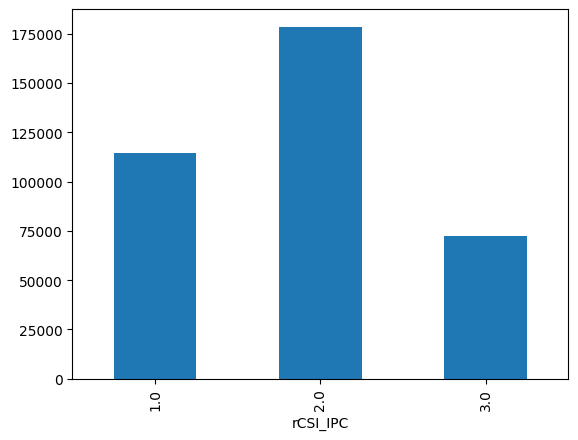

In [23]:
# plot the distribution of rCSI_IPC
data['rCSI_IPC'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='LCS_IPC'>

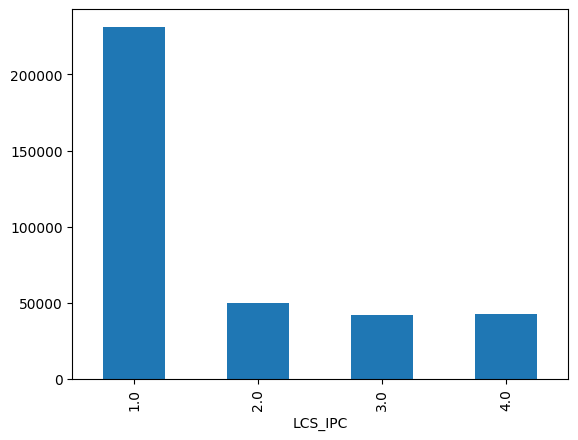

In [24]:
# plot the distribution of LCS_IPC
data['LCS_IPC'].value_counts().sort_index().plot(kind='bar')

In [25]:
#convert every variable start with hfc_ to numeric
for col in data.columns.tolist():
    if 'hfc_' in col:
        data[col] = pd.to_numeric(data[col], errors='coerce')

In [26]:
#define FCSStap as the max of hfc_graindays, hfc_rootsdays, skip missing
data['FCSStap'] = data[['hfc_graindays', 'hfc_rootsdays']].max(axis=1, skipna=True)
#define FCSPulse as hfc_pulsesnutsdays
data['FCSPulse'] = data['hfc_pulsesnutsdays']
#define FCSDairy as hfc_milkdays
data['FCSDairy'] = data['hfc_milkdays']
#define FCSPr as the max of hfc_meatdays, hfc_liverdays, hfc_fishdays, hfc_eggsdays, skip missing
data['FCSPr'] = data[['hfc_meatdays', 'hfc_liverdays', 'hfc_fishdays', 'hfc_eggsdays']].max(axis=1, skipna=True)
#define FCSVeg as the max of hfc_orangevegdays, hfc_greenleafydays, hfc_othervegdays, skip missing
data['FCSVeg'] = data[['hfc_orangevegdays', 'hfc_greenleafydays', 'hfc_othervegdays']].max(axis=1, skipna=True)
#define FCSFruits as the max of hfc_orangefruitsdays, hfc_otherfruitsdays, skip missing
data['FCSFruits'] = data[['hfc_orangefruitsdays', 'hfc_otherfruitsdays']].max(axis=1, skipna=True)
#define FCSFat as hfc_oildays
data['FCSFat'] = data['hfc_oildays']
#define FCSSugar as hfc_sugardays
data['FCSSugar'] = data['hfc_sugardays']
#define FCSCondiments as hfc_condimentsdays
data['FCSCond'] = data['hfc_condimentsdays']


In [27]:
# gen FCS = FCSStap*2 + FCSPulse*3 + FCSDairy*4 + FCSPr*4 + FCSVeg*1 + FCSFruit*1 + FCSFat*0.5 + FCSSugar*0.5
data['FCS'] = (data['FCSStap']*2 + data['FCSPulse']*3 + data['FCSDairy']*4 + data['FCSPr']*4 + data['FCSVeg']*1 + data['FCSFruits']*1 + data['FCSFat']*0.5 + data['FCSSugar']*0.5)

In [28]:
# code FCS_IPC as 1 if FCS >35, 3 if FCS > 21 and <=35, 4 if FCS <= 21
def FCS_to_FCS_IPC(FCS):
    if FCS > 35:
        return 1
    elif FCS > 21 and FCS <= 35:
        return 3
    elif FCS <= 21:
        return 4
    else:
        return None
    
data['FCS_IPC'] = data['FCS'].apply(FCS_to_FCS_IPC)


<Axes: xlabel='FCS_IPC'>

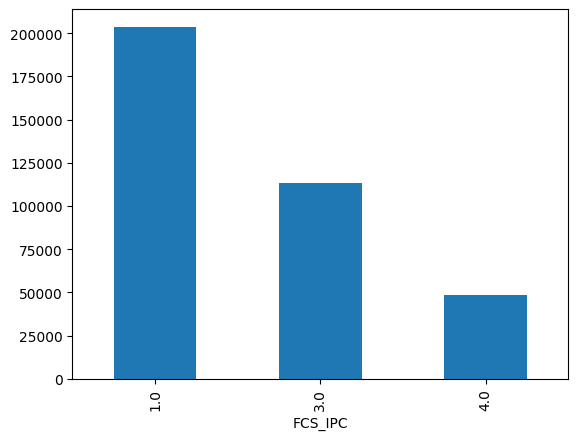

In [29]:
# FCS_IPC distribution
data['FCS_IPC'].value_counts().sort_index().plot(kind='bar')

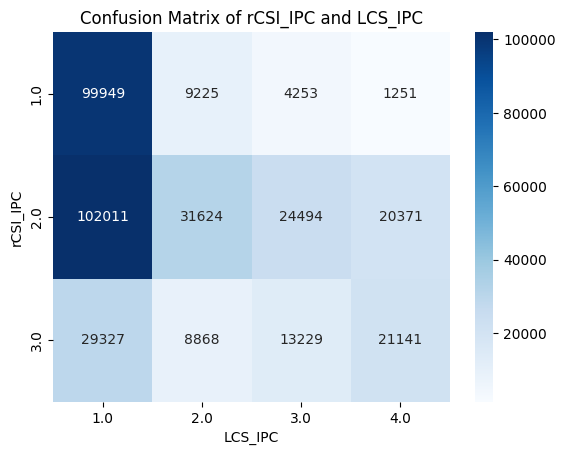

In [39]:
# plot rCSI_IPC and LCS_IPC confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
confusion_matrix = pd.crosstab(data['rCSI_IPC'], data['LCS_IPC'])
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('LCS_IPC')
plt.ylabel('rCSI_IPC')
plt.title('Confusion Matrix of rCSI_IPC and LCS_IPC')
plt.show()

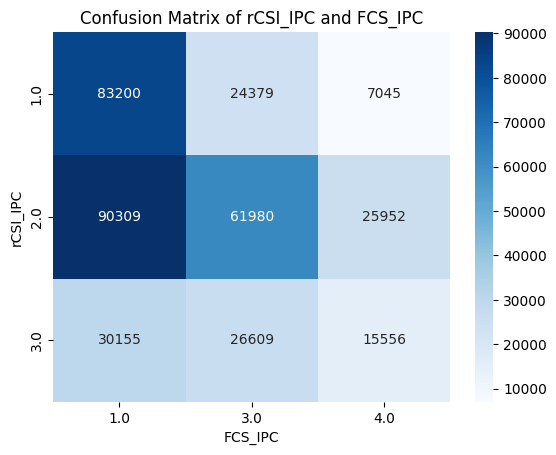

In [31]:
# do a rCSI_IPC and FCS_IPC confusion matrix
confusion_matrix = pd.crosstab(data['rCSI_IPC'], data['FCS_IPC'])
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('FCS_IPC')
plt.ylabel('rCSI_IPC')
plt.title('Confusion Matrix of rCSI_IPC and FCS_IPC')
plt.show()

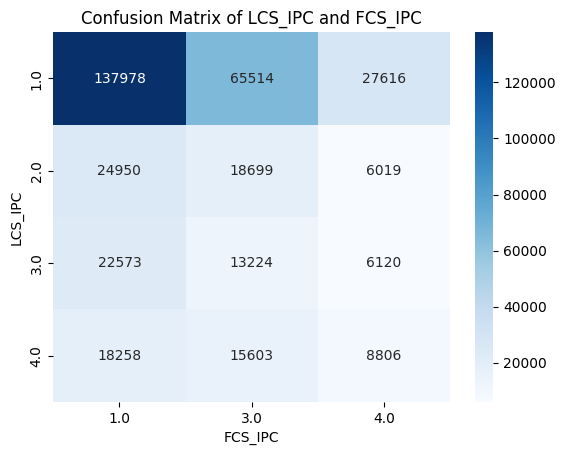

In [33]:
# do a LCS_IPC and FCS_IPC confusion matrix
confusion_matrix = pd.crosstab(data['LCS_IPC'], data['FCS_IPC'])
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('FCS_IPC')
plt.ylabel('LCS_IPC')
plt.title('Confusion Matrix of LCS_IPC and FCS_IPC')
plt.show()


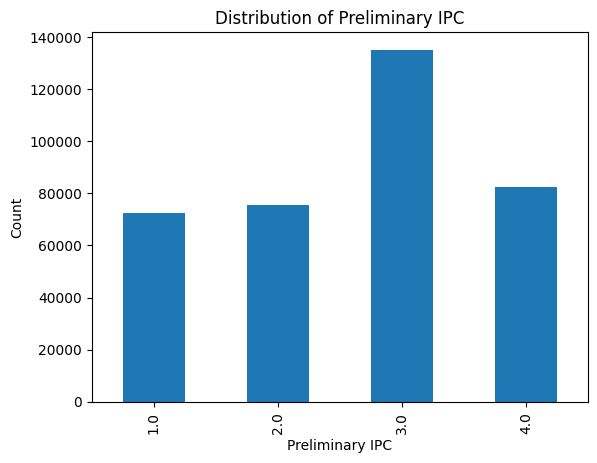

In [34]:
# preliminary IPC is the max of rCSI_IPC, LCS_IPC, FCS_IPC
data['preliminary_IPC'] = data[['rCSI_IPC', 'LCS_IPC', 'FCS_IPC']].max(axis=1)

# show distribution of preliminary_IPC
data['preliminary_IPC'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Preliminary IPC')
plt.ylabel('Count')
plt.title('Distribution of Preliminary IPC')
plt.show()